## Batch Normalization vs No Batch Normalization 

In [72]:
import torch

import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [73]:
X, y = make_classification(
    n_samples=2000,
    n_features=8,
    n_informative=6,
    n_classes=2,
    random_state=42
)

In [74]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [75]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [76]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1,1)

In [77]:
class BatchNormMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(8, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()

        )

    def forward(self, x):
        
        return self.net(x)
    


In [78]:
class NoBatchNormMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(8, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()

        )

    def forward(self, x):
        
        return self.net(x)

In [79]:
def train_model(model):

    criterion = nn.BCELoss()

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=20,
        gamma=0.1
    )

    train_losses = []
    val_losses = []
    lrs = []

    for epoch in range(60):

        model.train()

        preds = model(X_train)
        loss = criterion(preds, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # validation
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val)
            val_loss = criterion(val_preds, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        lr = optimizer.param_groups[0]['lr']
        lrs.append(lr)

        scheduler.step()

        print(f"Epoch {epoch+1} | Train {loss.item():.4f} | Val {val_loss.item():.4f} | LR {lr}")

    return train_losses, val_losses, lrs

In [80]:
modelA = BatchNormMLP()
modelB = NoBatchNormMLP()

print("Training model with BatchNorm...")
train_losses_A, val_losses_A, lrs_A = train_model(modelA)

print("\n" + "="*50 + "\n")

print("Training model without BatchNorm...")
train_losses_B, val_losses_B, lrs_B = train_model(modelB)

Training model with BatchNorm...
Epoch 1 | Train 0.6894 | Val 0.6388 | LR 0.01
Epoch 2 | Train 0.4937 | Val 0.5891 | LR 0.01
Epoch 3 | Train 0.4107 | Val 0.5418 | LR 0.01
Epoch 4 | Train 0.3652 | Val 0.4967 | LR 0.01
Epoch 5 | Train 0.3336 | Val 0.4540 | LR 0.01
Epoch 6 | Train 0.3075 | Val 0.4136 | LR 0.01
Epoch 7 | Train 0.2847 | Val 0.3762 | LR 0.01
Epoch 8 | Train 0.2649 | Val 0.3425 | LR 0.01
Epoch 9 | Train 0.2479 | Val 0.3126 | LR 0.01
Epoch 10 | Train 0.2333 | Val 0.2864 | LR 0.01
Epoch 11 | Train 0.2208 | Val 0.2638 | LR 0.01
Epoch 12 | Train 0.2099 | Val 0.2450 | LR 0.01
Epoch 13 | Train 0.2006 | Val 0.2297 | LR 0.01
Epoch 14 | Train 0.1928 | Val 0.2179 | LR 0.01
Epoch 15 | Train 0.1861 | Val 0.2086 | LR 0.01
Epoch 16 | Train 0.1803 | Val 0.2016 | LR 0.01
Epoch 17 | Train 0.1754 | Val 0.1962 | LR 0.01
Epoch 18 | Train 0.1710 | Val 0.1920 | LR 0.01
Epoch 19 | Train 0.1671 | Val 0.1887 | LR 0.01
Epoch 20 | Train 0.1636 | Val 0.1860 | LR 0.01
Epoch 21 | Train 0.1602 | Val 0.1841

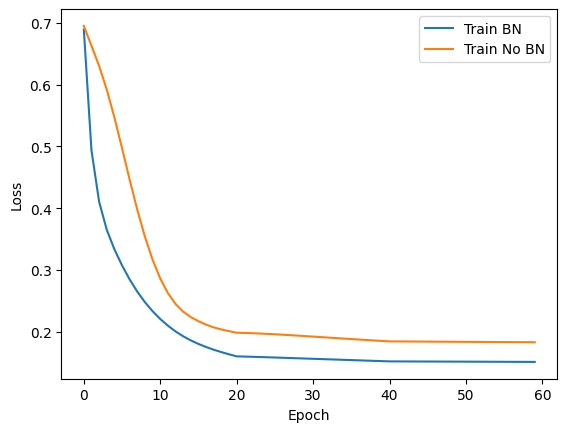

In [81]:
plt.plot(train_losses_A, label="Train BN")
plt.plot(train_losses_B, label="Train No BN")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

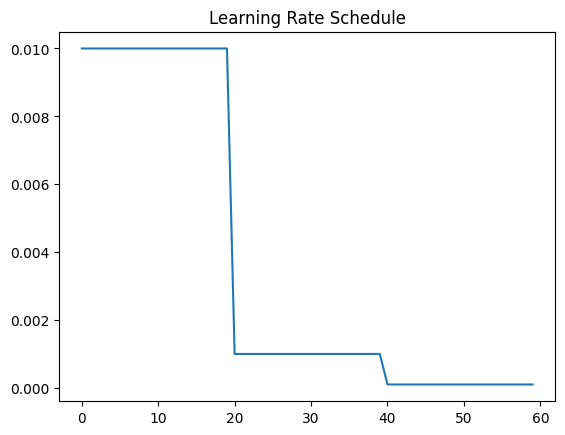

In [82]:
plt.plot(lrs_A)
plt.title("Learning Rate Schedule")
plt.show()

In [83]:
# | Metric             | No BN  | With BN |
# | ------------------ | ------ | ------- |
# | Training stability | worse  | better  |
# | convergence speed  | slower | faster  |
# | validation loss    | higher | lower   |